In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current and remaining:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                if neighbor not in visited and random.random() <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
        current = next_level
        time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0

    return spread_time, spread_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor = data[0], data[1]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [3]:
size = 10
for m in [3, 5, 7]:
    if not os.path.exists(f"fig_data/fig02/fig02_m{m:02d}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        BA_path = f"data/ba/ba_network_m{m:02d}_N{size:03d}K.pkl"
        BA_graphs = load_graphs(BA_path)
        print(f"Running simulation for m={m}:")
        for graph in tqdm(BA_graphs):
            graph_result = run_simulation_by_k(graph)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del BA_graphs
        with open(f"fig_data/fig02/fig02_m{m:02d}.pkl", "wb") as f:
            pickle.dump(result, f)
        del result

m: 3, A: 3.2550424546008374, B: -6.164363381490303
m: 5, A: 5.213516304234693, B: -9.702771074732226
m: 7, A: 5.349460320678524, B: -9.394932595218686
Fig 2a


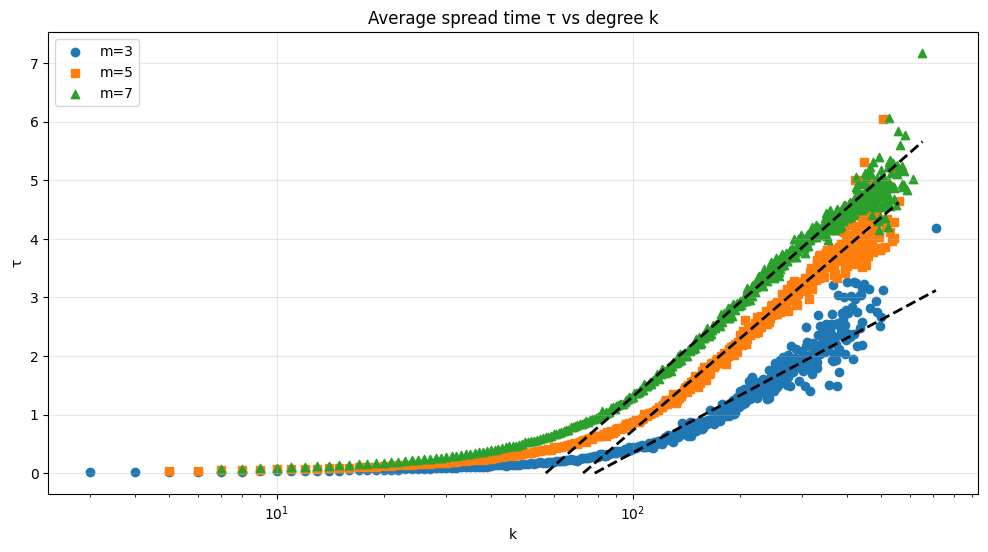

In [4]:
import matplotlib.pyplot as plt
import numpy as np
markers = {
    3: "o",   # circle
    5: "s",   # square
    7: "^",   # triangle
}

#Spread time
plt.figure(figsize=(12, 6))
for m in [3, 5, 7]:
    BA_data_by_k = load_graphs(f"fig_data/fig02/fig02_m{m:02d}.pkl")
    BA_plot_data_by_k = defaultdict(dict)
    for k in BA_data_by_k:
        BA_plot_data_by_k[k]["spread_time"] = sum(BA_data_by_k[k]["spread_time"]) / len(BA_data_by_k[k]["spread_time"])
    ks = np.array(sorted(BA_plot_data_by_k))
    spread_times = np.array([BA_plot_data_by_k[k]["spread_time"] for k in ks])

    plt.scatter(
        ks,
        spread_times,
        marker=markers.get(m, "o"),
        label=f"m={m}"
    )

    # Fit the later half of k values
    start = len(ks) // 6
    end = 7 *len(ks) // 8
    x_fit = np.log10(ks[start:end])
    y_fit = spread_times[start:end]
    a, b = np.polyfit(x_fit, y_fit, 1)
    x_line = np.logspace(-b / a, np.log10(ks[-1]), 200)
    y_line = a * np.log10(x_line) + b

    plt.plot(
        x_line,
        y_line,
        "k--",
        linewidth=2
    )

    print(f"m: {m}, A: {a}, B: {b}")

print("Fig 2a")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 2b


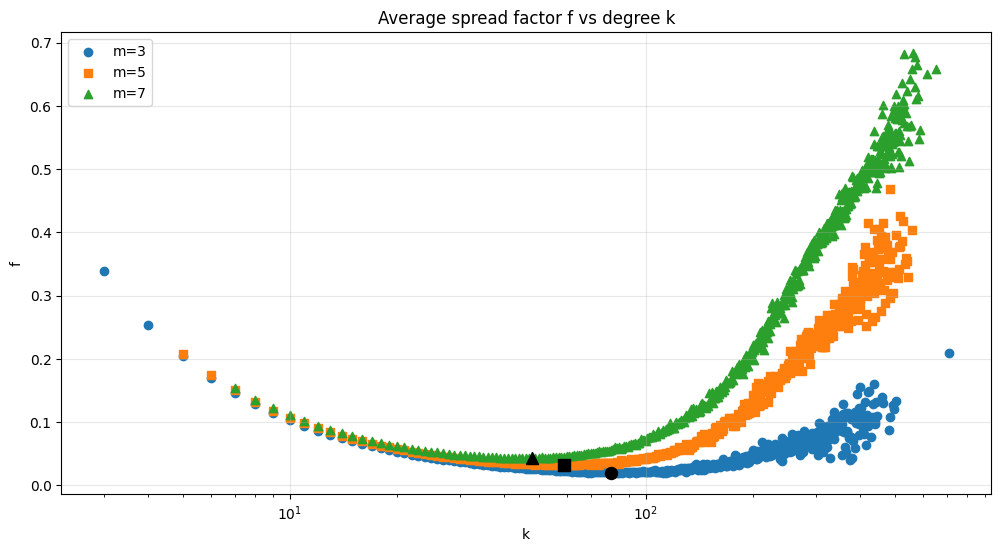

In [5]:
#Spread factor
plt.figure(figsize=(12, 6))

for m in [3, 5, 7]:
    BA_data_by_k = load_graphs(f"fig_data/fig02/fig02_m{m:02d}.pkl")
    BA_plot_data_by_k = defaultdict(dict) 
    for k in BA_data_by_k: 
        BA_plot_data_by_k[k]["spread_factor"] = sum(BA_data_by_k[k]["spread_factor"]) / len(BA_data_by_k[k]["spread_factor"])
    ks = sorted(BA_plot_data_by_k)
    spread_factors = [BA_plot_data_by_k[k]["spread_factor"]for k in ks]

    #k0
    idx = spread_factors.index(min(spread_factors))
    plt.scatter(
        ks[idx],
        spread_factors[idx],
        s=75,
        marker=markers.get(m, "o"),
        color="black",
        zorder=10
    )

    plt.scatter(
        ks,
        spread_factors,
        marker=markers.get(m, "o"),
        label=f"m={m}"
    )
    del BA_data_by_k, BA_plot_data_by_k

print("Fig 2b")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("f")
plt.title("Average spread factor f vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()